In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import copy
from WindPy import w
w.start()
from nav_function import *
import pyecharts.options as opts
from pyecharts.charts import Line
from pyecharts.globals import ThemeType
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

Welcome to use Wind Quant API for Python (WindPy)!

COPYRIGHT (C) 2024 WIND INFORMATION CO., LTD. ALL RIGHTS RESERVED.
IN NO CIRCUMSTANCE SHALL WIND BE RESPONSIBLE FOR ANY DAMAGES OR LOSSES CAUSED BY USING WIND QUANT API FOR Python.


In [2]:
class NavResearch:
    def __init__(self, nav_data_path, fund_name, benchmark_code, benchmark_name):
        self.nav_data_path = nav_data_path
        self.fund_name = fund_name
        self.benchmark_code = benchmark_code
        self.benchmark_name = benchmark_name

    # df_nav, df_return, df_drawdown
    def get_data(self):
        # nav data
        nav_df = pd.read_excel(self.nav_data_path, sheet_name=self.fund_name)
        nav_df = nav_df[["日期", "单位净值", "累计净值"]].rename(
            columns={"日期": "date", "单位净值": "nav_unit", "累计净值": "nav_accumulated"}
        )
        nav_df["date"] = pd.to_datetime(nav_df["date"])
        nav_df = nav_df.sort_values(by="date")
        nav_df["nav_unit"] = nav_df["nav_unit"] / nav_df["nav_unit"][0]
        nav_df["nav_accumulated"] = nav_df["nav_accumulated"] / nav_df["nav_accumulated"][0]
        nav_df = get_nav_adjusted(nav_df)
        # start_date, end_date
        start_date = pd.Timestamp(nav_df["date"].min()).strftime("%Y-%m-%d")
        end_date = pd.Timestamp(nav_df["date"].max()).strftime("%Y-%m-%d")
        # benchmark data
        error_code, benchmark_df = w.wsd(
            self.benchmark_code, "close", start_date, end_date, "Fill=Previous", usedf=True
        )
        benchmark_df.reset_index(inplace=True)
        benchmark_df.columns = ["date", self.benchmark_code]
        benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])
        benchmark_df[self.benchmark_code] = benchmark_df[self.benchmark_code] / benchmark_df[self.benchmark_code][0]
        # df_nav
        df = pd.merge(nav_df, benchmark_df, on="date", how="left")
        df["excess_nav"] = df["nav_adjusted"] - df[self.benchmark_code] + 1
        df_nav = df[
            ["date", "nav_unit", "nav_accumulated", "nav_adjusted", self.benchmark_code, "excess_nav"]
        ].round(4)
        # df_return
        df["nav_return"] = df["nav_adjusted"].pct_change()
        df["benchmark_return"] = df[self.benchmark_code].pct_change()
        df[["nav_return", "benchmark_return"]] = df[
            ["nav_return", "benchmark_return"]
        ].fillna(0)
        df["excess_return"] = df["nav_return"] - df["benchmark_return"]
        df_return = df[["date", "nav_return", "benchmark_return", "excess_return"]].round(4)
        # df_drawdown
        df_nav_copy = df_nav.copy()
        # fund_drawdown
        df_nav_copy["fun_max_so_far"] = df_nav_copy["nav_adjusted"].cummax()
        df_nav_copy["fund_drawdown"] = (
            df_nav_copy["nav_adjusted"] - df_nav_copy["fun_max_so_far"]
        ) / df_nav_copy["fun_max_so_far"]
        # benchmark_drawdown
        df_nav_copy["benchmark_max_so_far"] = df_nav_copy[self.benchmark_code].cummax()
        df_nav_copy["benchmark_drawdown"] = (
            df_nav_copy[self.benchmark_code] - df_nav_copy["benchmark_max_so_far"]
        ) / df_nav_copy["benchmark_max_so_far"]
        # excess_drawdown
        df_nav_copy["excess_max_so_far"] = df_nav_copy["excess_nav"].cummax()
        df_nav_copy["excess_drawdown"] = (
            df_nav_copy["excess_nav"] - df_nav_copy["excess_max_so_far"]
        ) / df_nav_copy["excess_max_so_far"]
        df_drawdown = df_nav_copy[
            ["date", "fund_drawdown", "benchmark_drawdown", "excess_drawdown"]
        ].round(4)
        self.df_nav = df_nav
        self.df_return = df_return
        self.df_drawdown = df_drawdown
        return self.df_nav, self.df_return, self.df_drawdown
    
    def get_plot(self):
        # data
        df_nav_ = self.df_nav.copy()
        # fund_drawdown
        df_nav_["fun_max_so_far"] = df_nav_["nav_adjusted"].cummax()
        df_nav_["fund_drawdown"] = (
            df_nav_["fun_max_so_far"] - df_nav_["nav_adjusted"]
        ) / df_nav_["fun_max_so_far"]
        # benchmark_drawdown
        df_nav_["benchmark_max_so_far"] = df_nav_[self.benchmark_code].cummax()
        df_nav_["benchmark_drawdown"] = (
            df_nav_["benchmark_max_so_far"] - df_nav_[self.benchmark_code]
        ) / df_nav_["benchmark_max_so_far"]
        # excess_drawdown
        df_nav_["excess_max_so_far"] = df_nav_["excess_nav"].cummax()
        df_nav_["excess_drawdown"] = (
            df_nav_["excess_max_so_far"] - df_nav_["excess_nav"]
        ) / df_nav_["excess_max_so_far"]
        # plot
        fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(25, 14))
        # 画超额收益图
        ax1.plot(
            df_nav_["date"], df_nav_["nav_adjusted"] - 1, color="red", label="累计收益"
        )
        ax1.plot(
            df_nav_["date"], df_nav_[self.benchmark_code] - 1, color="blue", label=self.benchmark_name
        )
        ax1.fill_between(
            df_nav_["date"], df_nav_["excess_nav"] - 1, color="gray", label="超额收益"
        )
        ax1.legend(loc="upper left", fontsize=15)
        ax1.tick_params(axis="x", rotation=45, labelsize=15)
        ax1.tick_params(axis="y", labelsize=15)
        ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax1.set_title("超额收益及动态回撤图", size=25)
        ax1.grid()
        # 画动态回撤图
        ax2.plot(df_nav_["date"], -df_nav_["fund_drawdown"], color="red", label="基金回撤")
        ax2.plot(
            df_nav_["date"], -df_nav_["benchmark_drawdown"], color="blue", label="基准回撤"
        )
        ax2.fill_between(
            df_nav_["date"], -df_nav_["excess_drawdown"], color="gray", label="超额回撤"
        )
        ax2.legend(loc="lower left", fontsize=15)
        ax2.tick_params(axis="x", rotation=45, labelsize=15)
        ax2.tick_params(axis="y", labelsize=15)
        ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax2.grid()
        return plt.show()

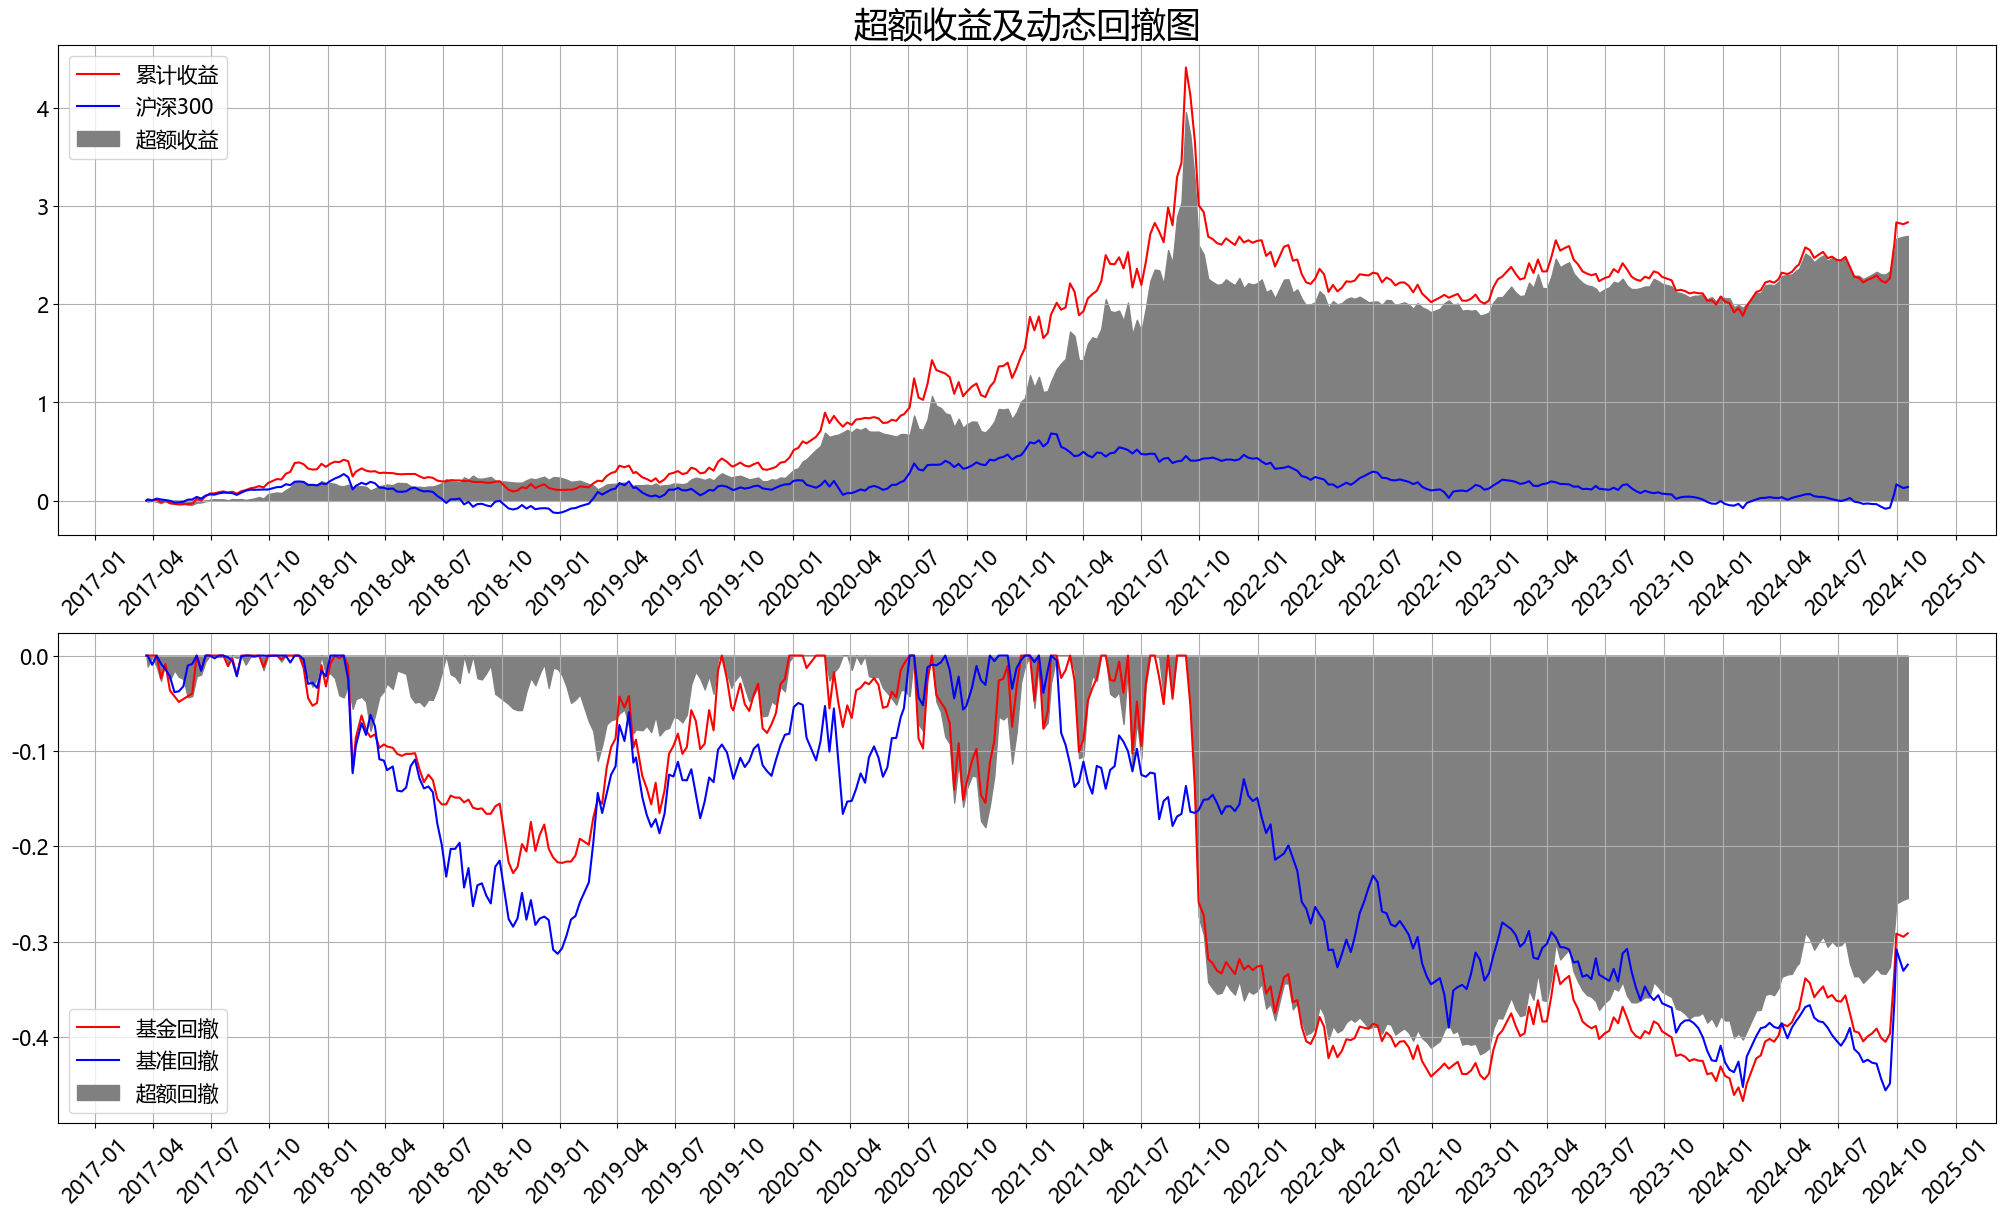

In [3]:
nav_research = NavResearch(r"E:\桌面文件\Private_nav_research\data_fund.xlsx","红筹长线3号","000300.SH","沪深300")
nav_research.get_data()
nav_research.get_plot()

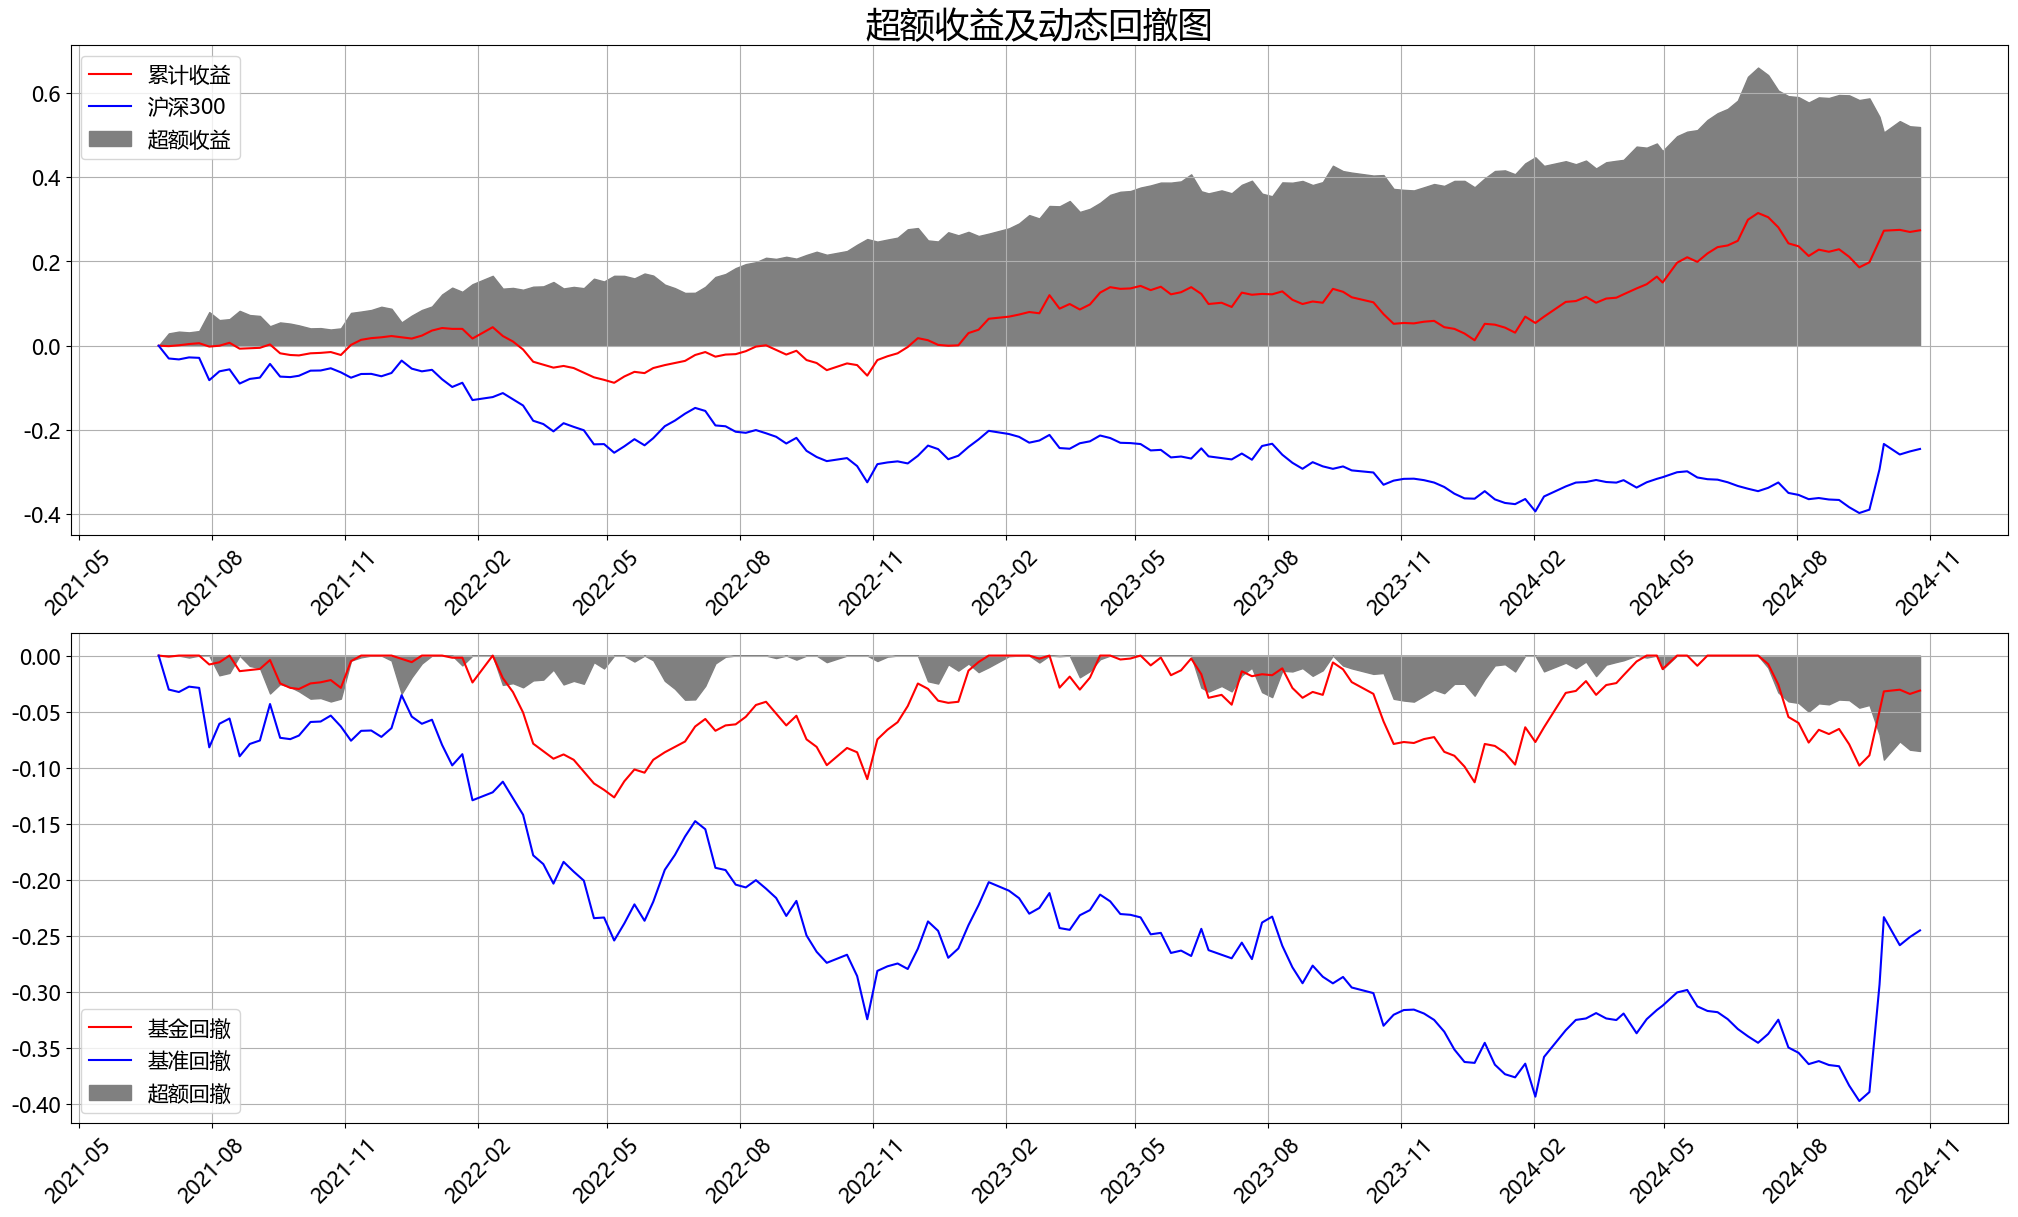

In [4]:
demo = NavResearch(r"E:\桌面文件\Private_nav_research\data_fund.xlsx","睿郡财富11号1期","000300.SH","沪深300")
demo.get_data()
demo.get_plot()

In [2]:
nav_data_path = r"C:\Users\17820\Desktop\Private_nav_research\data_fund.xlsx"
fund_name = "红筹长线3号"
benchmark_code = "000300.SH"
benchmark_name = "沪深300"
post_viewpoint_content = ""
data_nav, data_return, data_drawdown = get_data(nav_data_path, fund_name, benchmark)
freq = infer_frequency(data_nav)
basic_info_table = get_basic_info(data_nav, fund_name, benchmark_name)
nav_ratio_table = get_nav_ratio(data_nav, data_return, data_drawdown,freq)
year_return_table = get_year_return(data_nav, fund_name, benchmark, benchmark_name)
nav_drawdown_table = get_drawdown_info(data_nav, data_drawdown, -0.1)
nav_line = get_nav_lines(data_nav, fund_name, benchmark_name)
drawdown_line = get_drawdown_lines(data_drawdown, fund_name, benchmark_name)
get_html(data_nav, fund_name, post_viewpoint_content, basic_info_table, nav_ratio_table, year_return_table, nav_drawdown_table, nav_line, drawdown_line)

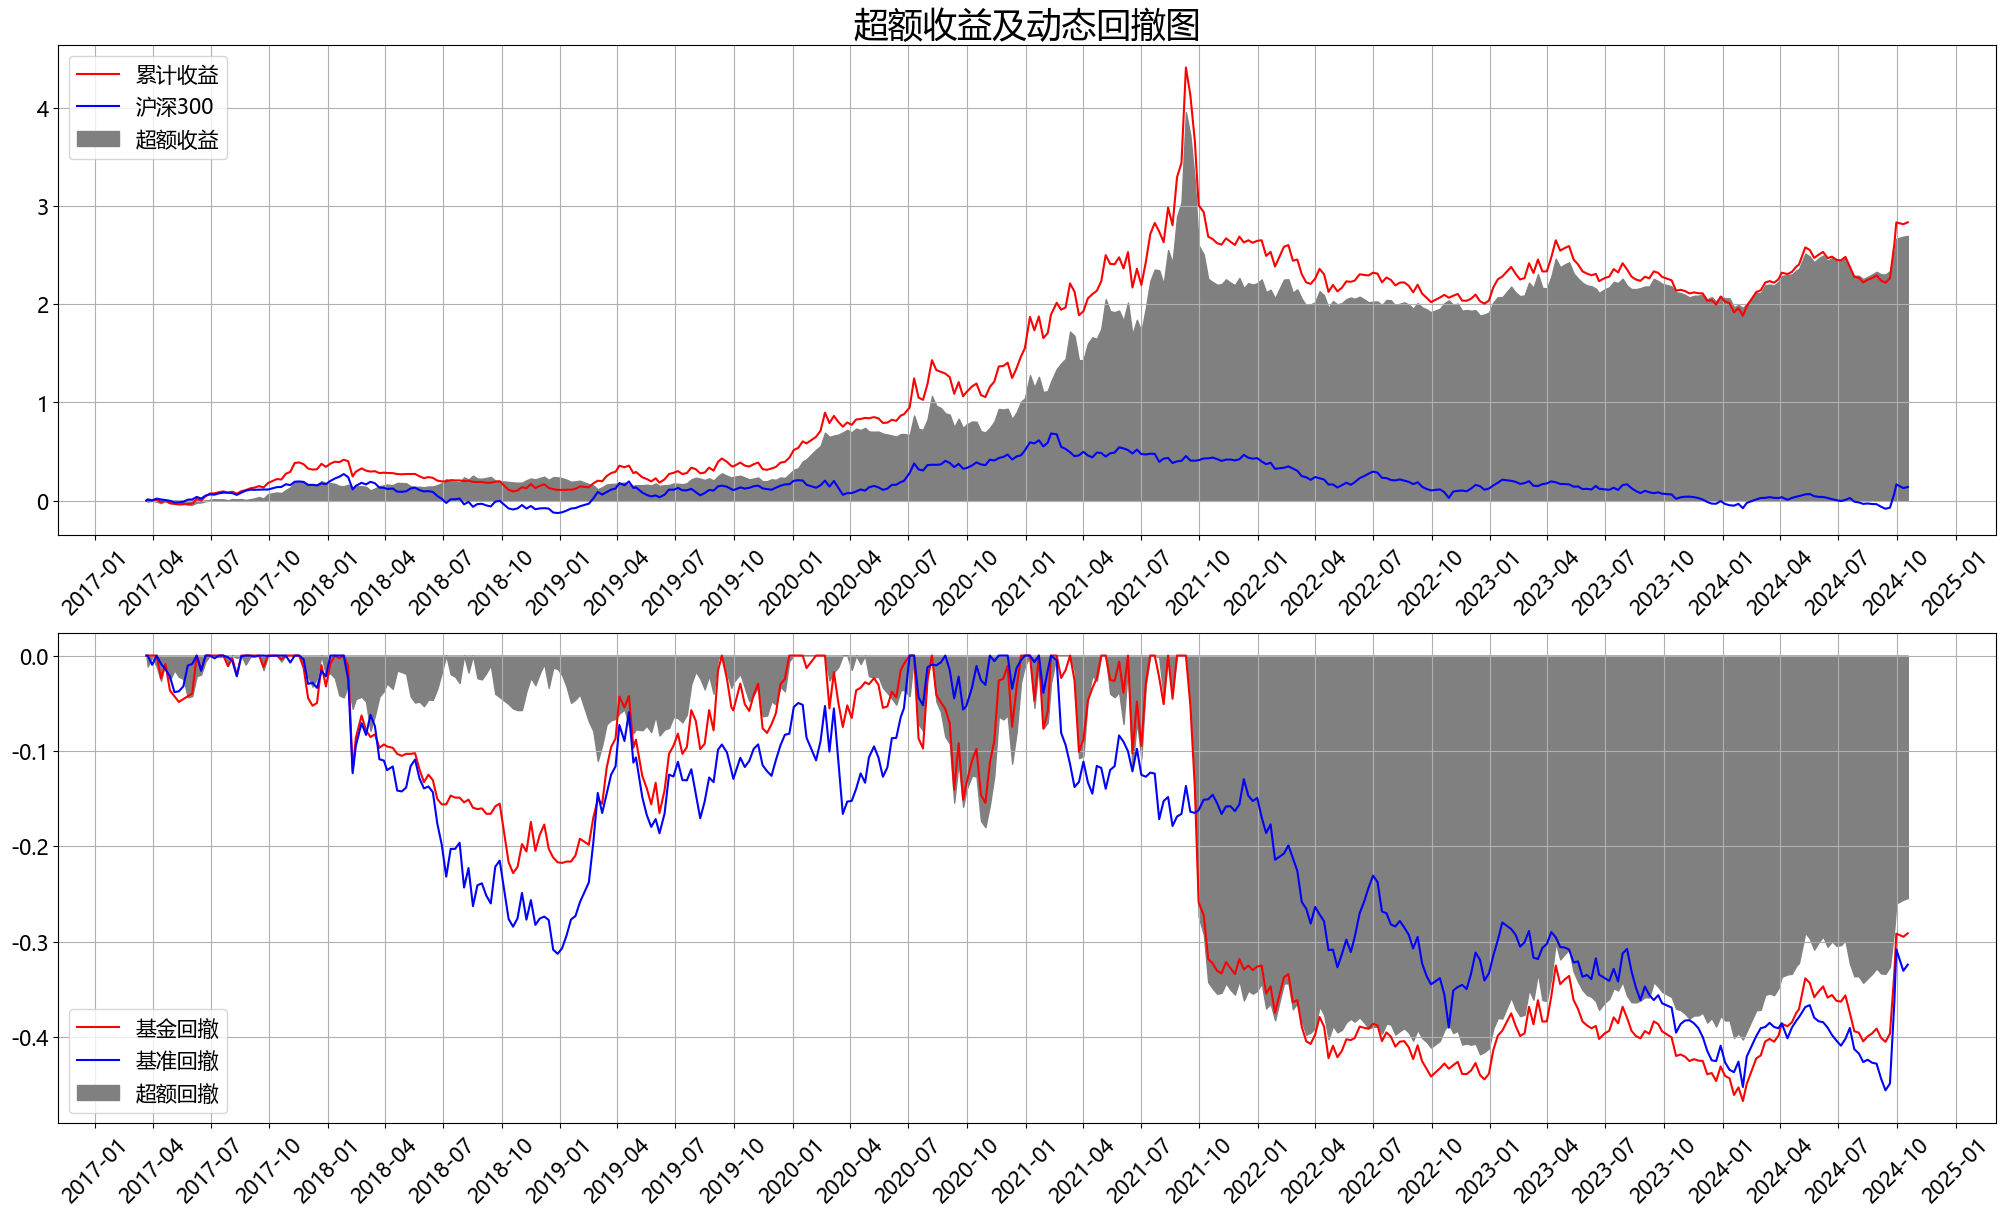

In [3]:
get_plot(data_nav, benchmark, benchmark_name)

post_viewpoint_content = """  
<div class="post-viewpoint">    
    <h2>后维观点：择机加仓</h2>    
    <p>产品亮点</p>  
    <p>1、过往三年，产品业绩稳健，超额优势突出。代表性老产品睿郡财富11号1期，2021/6/23-2024/10/18,整体业绩，年化收益7.69%，最大回撤-12.64%，年化波动率10.57%；分年度业绩，2021(6.23-12.31)收益3.60%、2022收益-3.38%、2023收益5.09%、2024(截至10.18)收益21.10%。</p>  
    <p>2、多资产表达投资观点。投资覆盖A股、港股、可转债、ETF等多资产，能以最具性价比的资产表达投资观点。股票和可转债业绩贡献1:1，可转债也是器核心能力圈。</p>  
    <p>3、投研团队实力强大，配合默契。①基金经理：5位基金经理均为“兴全系”知名公募基金经理，投资理念契合，平均从业年超过20年。②投研团队：共27人，分为5个行业组，覆盖消费医药、 TMT、新能源与装备制造业、新材料、可转债。</p>  
    <p>4、基金经理经验丰富，当前处于规模红利期。①从业经验：基金经理王晓明27年从业经历，20年+投资经验，经历多轮牛熊，市场应对经验丰富。21年底市场转熊的过程中，比较及时的把仓位聚焦到防御性成长的通信和公用事业行业，过去3年超额优势突出，熊市也帮助投资者赚了不少钱。②管理规模：王晓明管理规模40亿。</p>  
    <p>推荐逻辑</p>  
    <p>1、市场转向确立，暴力拉升阶段过去，市场结构分化回归理性，需要优质私募基金经理帮助投资者精选投资方向和个股。</p>  
    <p>2、央行首次创设两项结构性政策工具“互换便利”和“股票回购，增持再贷款”支持资本市场，也利好红利股。</p>  
    <p>3、睿郡针对当前市场情况睿郡已经做好了两手准备，一种是宏观经济继续下滑一段时间，继续布局防御性成长；另一种是宏观经济大幅好转，逐步减少防御性成长仓位，布局顺周期反弹更快的行业，如港股互联网，创新药和半导体等，目前已经有一部分仓位。</p> 
</div>  
""" 

In [6]:
import datetime
days_diff = (datetime.datetime(2024, 11 ,1) - datetime.datetime(2021, 1, 1)).days
annual_return = pow(1 + 0.6341, 365 / days_diff) - 1
print(annual_return)

0.13659249928014394
